In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import iconspy as ispy
from iconspy.tests.conftest import get_ds_tgrid_lr
from iconspy.demo_helpers import setup_plot_area_quickstart, setup_plot_area_mar

In [2]:
ds_tgrid = get_ds_tgrid_lr()
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)
ds_IsD

<xarray.Dataset> Size: 7MB
Dimensions:                 (cell: 15105, vertex: 8067, edge: 23207, nc_e: 2,
                             nv_c: 3, ne_c: 3, nv_v: 6, ne_v: 6, nv_e: 2,
                             nc_v: 6, nc_c: 3, cart: 3)
Coordinates:
  * cell                    (cell) int32 60kB 0 1 2 3 ... 15102 15103 15104
    clon                    (cell) float64 121kB 69.12 73.0 ... 74.57 76.01
    clat                    (cell) float64 121kB 72.74 74.52 ... -46.83 -44.85
  * vertex                  (vertex) int32 32kB 0 1 2 3 ... 8063 8064 8065 8066
    vlon                    (vertex) float64 65kB 73.0 69.39 ... 80.59 77.56
    vlat                    (vertex) float64 65kB 73.27 71.49 ... -45.35 -45.49
  * edge                    (edge) int32 93kB 0 1 2 3 ... 23204 23205 23206
    elon                    (edge) float64 186kB 71.11 76.98 ... 75.34 76.04
    elat                    (edge) float64 186kB 72.39 73.25 ... -46.52 -45.54
Dimensions without coordinates: nc_e, nv_c, ne_c, nv_v, ne_v, nv_e, nc_v, nc_c,
                                cart
Data variables: (12/41)
    grid_sphere_radius      float64 8B 6.371e+06
    grav                    float64 8B 9.807
    earth_angular_velocity  float64 8B 7.292e-05
    rho0                    float64 8B 1.025e+03
    rhoi                    float64 8B 917.0
    rhos                    float64 8B 300.0
    ...                      ...
    dual_edge_cart_vec      (edge, cart) float64 557kB 0.09801 ... -0.7136
    edge_prim_norm          (edge, cart) float64 557kB 0.6463 -0.7466 ... 0.7001
    fc                      (cell) float64 121kB 0.0001393 ... -0.0001029
    fe                      (edge) float64 186kB 0.000139 ... -0.0001041
    fv                      (vertex) float64 65kB 0.0001397 ... -0.000104
    boundary_vertex_mask    (vertex) bool 8kB True True False ... False False
Attributes:
    converted_tgrid:      True
    boundary_BallTree:    <iconspy.balltree.IspyBoundaryBallTree object at 0x...
    wet_BallTree:         <iconspy.balltree.IspyWetBallTree object at 0x30baa...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    IsD_compatible_flag:  True

In [4]:
ds_nodes = xr.open_dataset("meshes/NG5_griddes_nodes_IFS.nc")
ds_elems = xr.open_dataset("meshes/NG5_griddes_elems_IFS.nc")

In [5]:
ds_FsD["coast_c"].plot()

NameError: name 'ds_FsD' is not defined

In [15]:
def convert_fmesh_data(ds_nodes, ds_elems):
    # Nodes are vertices are scalar points
    ds_nodes = ds_nodes.rename(
        grid_size="vertex",
        grid_center_lat="vlat",
        grid_center_lon="vlon",
        nlinks_max="nv_v",
        node_node_links="vertices_of_vertex",
        depth="depth_v",
        nlev="depth",
        ntriags="cell",
        Three="nv_c",
        triag_nodes="vertex_of_cell",
        grid_imask="lsm_v",
        nlev_bnds="depth_bnds",
        grid_corners="vertex_bnds",
        grid_corner_lat="vlat_bnds",
        grid_corner_lon="vlon_bnds",
        coast="coast_v",
        cell_area="dual_area"
    ).drop_vars(["grid_dims", "depth_bnds"])
    
    ds_elems = ds_elems.rename(
        grid_size="cell",
        grid_center_lon="clon",
        grid_center_lat="clat",
        ncells="vertex",
        node_node_links="vertices_of_vertex",
        nlinks_max="nv_v",
        grid_imask="lsm_c",
        grid_corners="cell_bnds",
        grid_corner_lat="clat_bnds",
        grid_corner_lon="clon_bnds",
        coast="coast_c",
        triag_nodes="vertex_of_cell",
    ).drop_vars(["grid_dims", "vertex_of_cell", "vertices_of_vertex"])
    
    ds_FsD = xr.merge(
        [ds_nodes, ds_elems]
    ).assign_attrs(
        IsD_compatible_flag=True
    )
    
    ds_FsD["vertices_of_vertex"] = ds_FsD["vertices_of_vertex"].astype("int32") - 1
    ds_FsD["vertex_of_cell"] = ds_FsD["vertex_of_cell"].astype("int32") - 1

    ds_FsD["cell_sea_land_mask"] = -1 * ds_FsD["lsm_c"]
    ds_FsD["boundary_vertex_mask"] = (ds_FsD["coast_v"] == 1)

    boundary_BallTree = ispy.balltree.IspyBoundaryBallTree(ds_FsD)
    wet_BallTree = ispy.balltree.IspyWetBallTree(ds_FsD)
    ds_FsD = ds_FsD.assign_attrs(
        {
            "boundary_BallTree": boundary_BallTree,
            "wet_BallTree": wet_BallTree,
            "uuidOfHGrid": "0000",
        }
    )
    
    return ds_FsD

ds_FsD = convert_fmesh_data(ds_nodes, ds_elems)

/opt/homebrew/Caskroom/mambaforge/base/envs/ispy/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:277: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


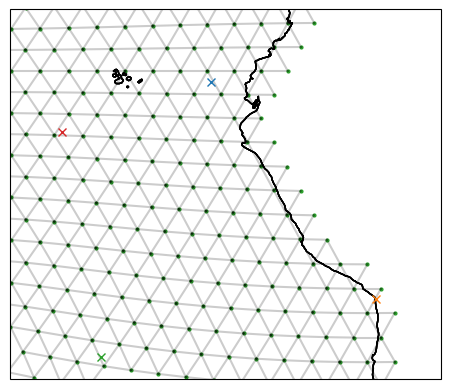

In [17]:
target_ne_corner = ispy.TargetStation("NE Corner", -83.72, -0.928, boundary=True)
target_nw_corner = ispy.TargetStation("NW Corner", -95.794, -4.976, boundary=None)
target_sw_corner = ispy.TargetStation("SW Corner", -92.592, -23.219, boundary=False)
target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

fig, ax = setup_plot_area_quickstart(ds_IsD)

target_ne_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)

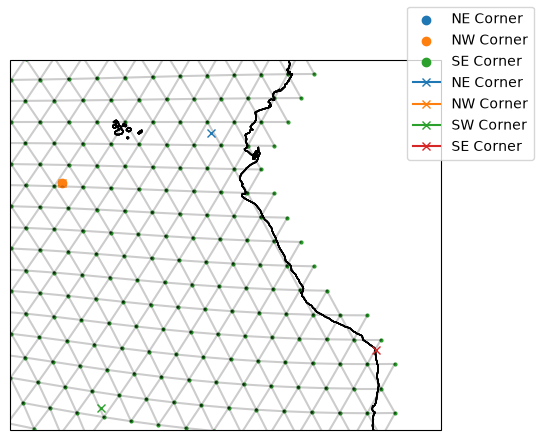

In [20]:
# Convert the target stations to model stations
model_ne_corner = target_ne_corner.to_model_station(ds_FsD)
model_nw_corner = target_nw_corner.to_model_station(ds_FsD)
# model_sw_corner = target_sw_corner.to_model_station(ds_FsD)
model_se_corner = target_se_corner.to_model_station(ds_FsD)

fig, ax = setup_plot_area_quickstart(ds_IsD)

# Plot the model stations (circles)
model_ne_corner.plot(ax=ax, gridlines=False)
model_nw_corner.plot(ax=ax, gridlines=False)
# model_sw_corner.plot(ax=ax, gridlines=False)
model_se_corner.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)

fig.legend()

In [29]:
model_ne_corner.model_lat

-74.5806370981096